In [11]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn import tree
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
def load_data(filepath):
    """
    Loads the car dataset from a CSV file and extracts
    features (Volume, Doors) and target (Style).
    """
    df = pd.read_csv(filepath)
    features = df[["Volume", "Doors"]]
    target = df["Style"]
    return features, target, df

In [13]:
def split_data(features, target, test_size=0.2, random_state=3):
    """
    Splits features and target into training and testing sets.

    """
    return train_test_split(features, target, test_size=test_size, random_state=random_state)

In [14]:
def train_decision_tree(X_train, y_train):
    """
    Trains a Decision Tree classifier on the training data.

    """
    decisionTree = DecisionTreeClassifier(random_state=3)
    decisionTree.fit(X_train, y_train)
    return decisionTree

In [15]:
def save_tree_image(decisionTree, feature_names, class_names, output_path="TreeCars.png"):
    """
    Saves a visual representation of the decision tree as a PNG file.


    """
    plt.figure(figsize=(20, 10))
    tree.plot_tree(
        decisionTree,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Decision tree saved to {output_path}")

In [16]:
def save_tree_cars_csv(X_test, y_test, predicted_styles, accuracy, output_path="TreeCars.csv"):
    """
    Saves the test set predictions to a CSV file, with an accuracy
    row appended at the bottom.

    """
    # Build the results dataframe with original Volume, Doors, true Style, and predicted Style
    results_df = X_test.copy()
    results_df["Style"] = y_test.values
    results_df["PredictedStyle"] = predicted_styles

    # Append a summary accuracy row at the bottom
    accuracy_row = pd.DataFrame([["" , "", "Accuracy", round(accuracy, 4)]],
                                 columns=["Volume", "Doors", "Style", "PredictedStyle"])
    results_df = pd.concat([results_df, accuracy_row], ignore_index=True)

    results_df.to_csv(output_path, index=False)
    print(f"TreeCars.csv saved to {output_path}")

Test Set Accuracy: 0.6333


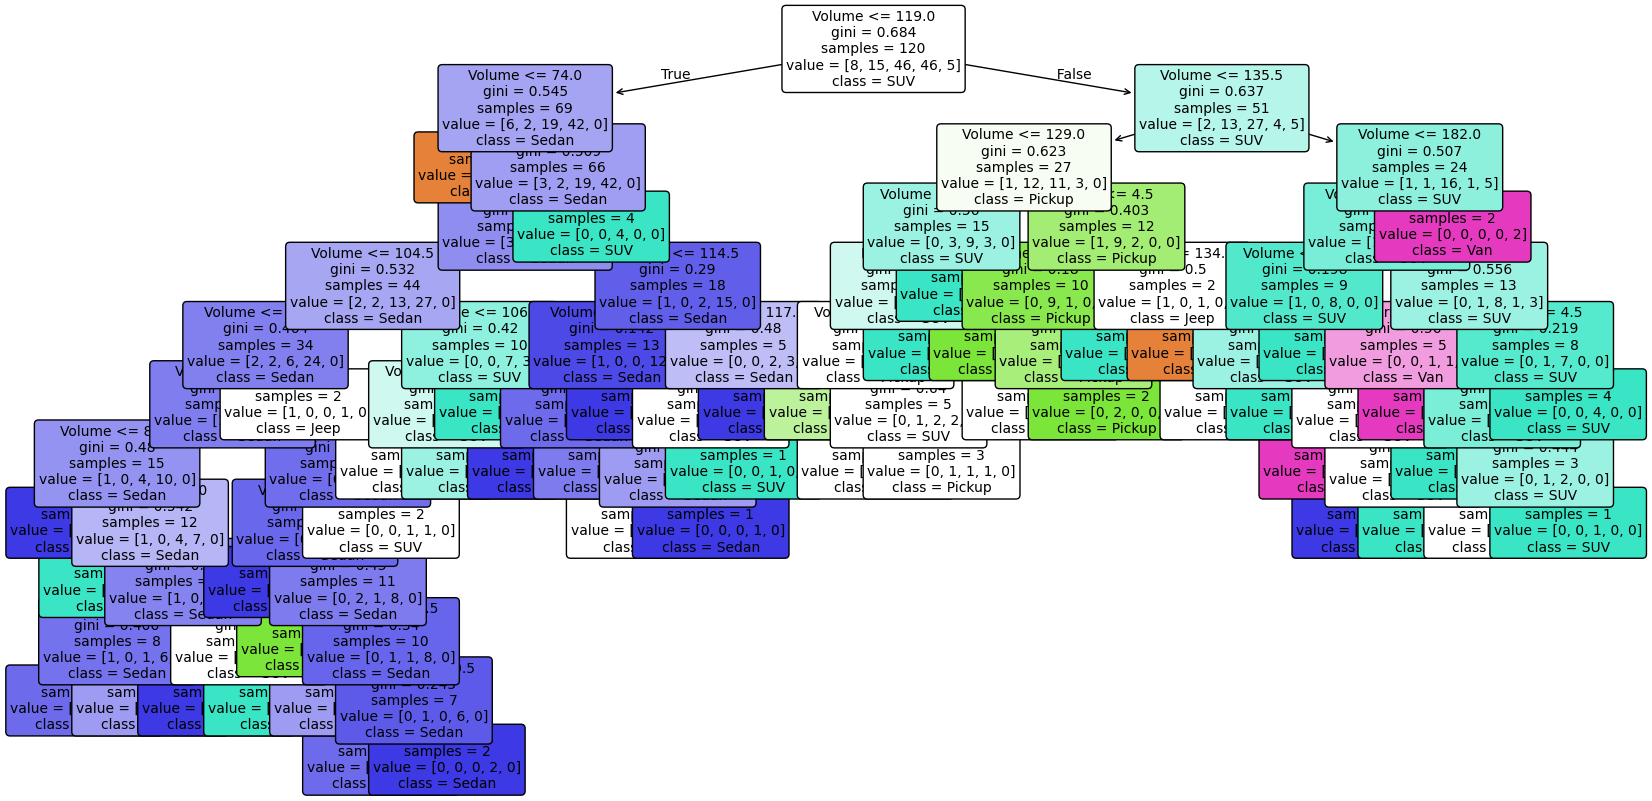

Decision tree saved to TreeCars.png
TreeCars.csv saved to TreeCars.csv


In [17]:
# Load the dataset
features, target, df = load_data("/content/drive/MyDrive/Colab Notebooks/AllCars.csv")

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = split_data(features, target, test_size=0.2, random_state=3)

# Train the decision tree on the training set
decisionTree = train_decision_tree(X_train, y_train)

# Predict styles for the test set
predicted_styles = decisionTree.predict(X_test)

# Compute overall accuracy
accuracy = accuracy_score(y_test, predicted_styles)
print(f"Test Set Accuracy: {accuracy:.4f}")

# Save the decision tree as a PNG
save_tree_image(
    decisionTree,
    feature_names=["Volume", "Doors"],
    class_names=sorted(target.unique()),
    output_path="TreeCars.png"
)

# Save the predictions CSV with accuracy row at the bottom
save_tree_cars_csv(X_test, y_test, predicted_styles, accuracy, output_path="TreeCars.csv")